In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Fabric Data

In [4]:
fabric = pd.read_excel("Fabric data.xlsx")
fabric.head()


,Fabric_length
0,151.2
1,160.3
2,147.5
3,149.2
4,159.2


**Step 1. Formula of Ho, Ha*
 - Ho: Meaan >= 150
 - Ha: Mean < 150

**Step 2. Select Level of significance**
- alpha = 0.05

**Step 3. Check for Normality**


In [5]:
# option 1 -- skewness

fabric.Fabric_length.skew()

np.float64(0.29650632012590666)

C:\Users\abhay\AppData\Local\Temp\ipykernel_31628\2639746944.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fabric.Fabric_length)


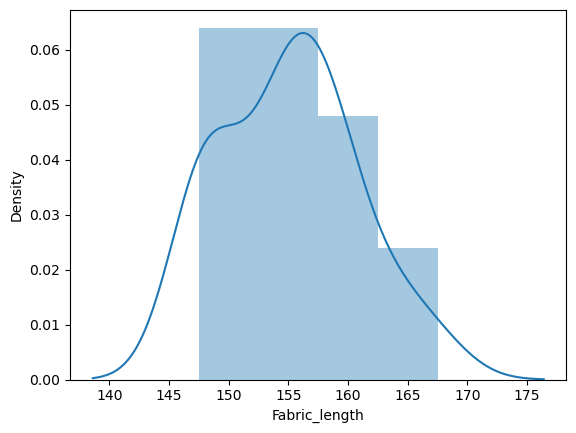

In [13]:
# Option 2 -- Density Curve

sns.distplot(fabric.Fabric_length)
plt.show()

In [15]:
# option3 -- Shapiro Test

stats.shapiro(fabric.Fabric_length)

ShapiroResult(statistic=np.float64(0.9397524078584506), pvalue=np.float64(0.1460935830606142))

**Step 4: Select the statistical test and calculate p value**

- 1 sample Z test

In [19]:
fabric.Fabric_length.mean()

np.float64(155.064)

In [18]:
z_cal = (fabric.Fabric_length.mean() - 150)/(4/ np.sqrt(25))
print(z_cal)

6.329999999999991


**Step 5: Based on p value, Accept or Reject H0**

- P > alpha
- P high -- Null fly
- Do not Reject H0

## Bolt Diameter

In [20]:
bolt = pd.read_excel('Bolt diameter.xlsx')
bolt.head()

,Diameter
0,11.27
1,12.06
2,12.15
3,9.89
4,10.82


**1. Formulation of H0,Ha**
- H0: Mean = 10
- Ha: Mean != 10

**2. Select Level of significance**
- alpha = 0.05

**3. Check for Normality**


In [21]:
bolt.Diameter.skew()

np.float64(0.380916607218941)

**4. Select the Statistical test & Calculate the p value**
- 1 sample T test

In [22]:
stats.ttest_1samp(bolt.Diameter, 10)

TtestResult(statistic=np.float64(4.1146847709314756), pvalue=np.float64(0.0005896412896356807), df=np.int64(19))

**5. Based on p value, Accept or Reject h0**
- P < alpha 
- P low -- Null go
- Reject H0 (Average bolt diameter is not equal to to) ---> take action

## Creditcart Promotion

In [24]:
promotion = pd.read_excel('Promotion.xlsx')
promotion.head()

,InterestRateWaiver,StandardPromotion
0,1989.10,1272.25
1,1808.38,1250.38
2,1153.75,1474.78
3,1745.64,2064.89
4,1008.24,2030.87


**1. Formulation of H0, Ha**
- H0: Avg of purchases made by FIIW <= Avg purchases made by SC => default / current / no action
- Ha: Avg of purchases made by FIW > Avg purchases made by SC => take action

**2. Select Level of significance**
- alpha = 0.05

**3. Check for Normality**



In [26]:
print(stats.shapiro(promotion.InterestRateWaiver))

ShapiroResult(statistic=np.float64(0.9923668605850225), pvalue=np.float64(0.22460944304178543))


In [27]:
print(stats.shapiro(promotion.StandardPromotion))

ShapiroResult(statistic=np.float64(0.9919790893297836), pvalue=np.float64(0.1916020629878476))


**Variance test - Levene Test**
- H0: Variances are equal
- Ha: Variances are not equal

In [28]:
stats.levene(promotion.InterestRateWaiver, promotion.StandardPromotion)

LeveneResult(statistic=np.float64(1.1334674473666406), pvalue=np.float64(0.2875528565130808))

**4. Select the Statistical test & Calculate the p value**
- 2 sample t test for equal variance

In [29]:
stats.ttest_ind(promotion.InterestRateWaiver, promotion.StandardPromotion, equal_var=True)

TtestResult(statistic=np.float64(2.2604251631369405), pvalue=np.float64(0.02422584468584315), df=np.float64(498.0))

**5. Based on p value, Accept or Reject H0**

- P < alpha
- P low -- Null go 
- Reject H0 (FIW <= SC) --> take action

In [31]:
# ## Sample t test for unequal variance
# stats.ttest_ind(promotion.InterestRateWaiver, promotion.StandardPromotion, equal_var=True)

## Contract Revewal

In [32]:
cof = pd.read_excel('Contract Renewal.xlsx')
cof.head()

,SupplierA,SupplierB,SupplierC
0,6.15,7.87,7.41
1,6.22,5.21,3.61
2,6.76,7.94,7.23
3,4.29,7.36,5.53
4,7.08,6.17,3.97


**1. Formulation H0,Ha**
- Ho: Average time by all suppliers are equal
- Ha: Average time by all suppliers are not equal

**2. Select Level of significance**
- alpha = 0.05

**3. Check for Normallity**


In [33]:
print(stats.shapiro(cof.SupplierA))
print(stats.shapiro(cof.SupplierB))
print(stats.shapiro(cof.SupplierC))


ShapiroResult(statistic=np.float64(0.9940788430927858), pvalue=np.float64(0.8962103654176035))
ShapiroResult(statistic=np.float64(0.9912330085810608), pvalue=np.float64(0.6483890667842709))
ShapiroResult(statistic=np.float64(0.990415383031867), pvalue=np.float64(0.5718975538301782))


In [35]:
################## Variance test ############
stats.levene(cof.SupplierA, cof.SupplierB, cof.SupplierC)   ## All 3 supplyer being checked for variances


LeveneResult(statistic=np.float64(0.25183988720942463), pvalue=np.float64(0.7775071819400866))

In [36]:
################## Variance test ############
print(stats.levene(cof.SupplierA, cof.SupplierB))
print(stats.levene(cof.SupplierB, cof.SupplierC))
print(stats.levene(cof.SupplierC, cof.SupplierA))



LeveneResult(statistic=np.float64(0.03382395609148779), pvalue=np.float64(0.8542383784793752))
LeveneResult(statistic=np.float64(0.24333902699144816), pvalue=np.float64(0.6222596854892893))
LeveneResult(statistic=np.float64(0.4712013339466693), pvalue=np.float64(0.49310323292578306))


**4. Select the Statistical & Calculate the p value**
- Anova Test (F test)

In [37]:
stats.f_oneway(cof.SupplierA, cof.SupplierB, cof.SupplierC)

F_onewayResult(statistic=np.float64(2.280378701368123), pvalue=np.float64(0.10373295731933224))

**5. Based on p value, Accept or Reject H0**
- P > alpha
- P High Null Fly
- All the 3 suppliers have equal mean transaction tiime 

## Johny Talkers

In [42]:
df = pd.read_excel('JohnyTalkers.xlsx')
df.head()

,Person,Drinks
0,Adults,Did Not Purchase
1,Adults,Did Not Purchase
2,Adults,Did Not Purchase
3,Adults,Did Not Purchase
4,Adults,Did Not Purchase


In [43]:
df.Person.value_counts()

Person
Children    740
Adults      480
Name: count, dtype: int64

In [44]:
df.Drinks.value_counts()

Drinks
Did Not Purchase    1010
Purchased            210
Name: count, dtype: int64

In [45]:
# crosstable
pd.crosstab(df.Person, df.Drinks, margins=True)

Drinks,Did Not Purchase,Purchased,All
Person,,,
Adults,422,58,480
Children,588,152,740
All,1010,210,1220


**1. Formulatio of H0, Ha**

- H0: Proportions of Adults >= Proportions of Children
- Ha: Proportions of Adults < Proportions of Children

**2. Select Level of significance**
- alpha = 0.05

**3. Select the Statistical tst & Calculate the p value**
- 2 proportion test

In [48]:
from statsmodels.stats.proportion import proportions_ztest

count  = np.array([58, 152])  # How many adults and children are purchsing
nobs = np.array([480,740])   # Total number adults and children are there

proportions_ztest(count, nobs, alternative = 'two-sided')

(np.float64(-3.8227247718795447), np.float64(0.00013198507287726183))

**5. Based on p value, Accept or Reject H0**
- P < alpha
- P low Null go
- Reject H0
- Accept alternate hypothesis i.e. Unequal proportions

## Bahaman

In [49]:
Bahaman = pd.read_excel('Bahaman.xlsx')
Bahaman.head()

,Defective,Country
0,0,India
1,0,India
2,0,India
3,0,India
4,1,India


In [50]:
coun = pd.crosstab(Bahaman.Defective, Bahaman.Country)
count

array([ 58, 152])

**1. Formulation of H0, Ha**

- H0: No diffenece in proportion between countries
- H1: difference in proportion between countries

**2. Select Level of significance**
- alpha = 0.05

**4. Select the Statistical test & Calculate the p value**
- Chisquare test

In [51]:
stats.chi2_contingency(count)

Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=0, expected_freq=array([ 58., 152.]))

In [52]:
chisquare_resuls = stats.chi2_contingency(count)
print('p-value: ', chisquare_resuls[1])

p-value:  1.0


**5. Based on p value, Accept or Reject H0**
- P > alpha
-P high Null fly
- Accept H0